# Exploratory Analysis — Overture Roads × Colombian Municipalities

Run from the `notebooks/` directory, or open from repo root via Jupyter Lab/Notebook.

**Prerequisites:** Run all three scripts from the repo root before opening this notebook:

```bash
python src/1_audit_road_classes.py
python src/2_clip_and_aggregate.py
python src/3_zone_areas.py
```

**Inputs** (generated by the scripts above):

- `../data/outputs/overture_class_audit.csv`
- `../data/outputs/overture_roads_by_class.csv`
- `../data/outputs/zone_areas_km2.csv`

## 0. Setup & data loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

AUDIT_PATH = "../data/outputs/overture_class_audit.csv"
ROADS_PATH = "../data/outputs/overture_roads_by_class.csv"
AREAS_PATH = "../data/outputs/zone_areas_km2.csv"

audit = pd.read_csv(AUDIT_PATH)
roads = pd.read_csv(ROADS_PATH)
areas = pd.read_csv(AREAS_PATH)

roads["mpio_id"] = roads["mpio_id"].astype(str).str.zfill(5)
areas["mpio_id"] = areas["mpio_id"].astype(str).str.zfill(5)

print(f"Audit rows : {len(audit):,}  |  road classes: {audit['class'].nunique()}")
print(
    f"Roads rows : {len(roads):,}  |  municipios: {roads['mpio_id'].nunique()}  |  departamentos: {roads['departamento'].nunique()}"
)
print(
    f"Areas rows : {len(areas):,}  |  municipios: {areas['mpio_id'].nunique()}  |  zone types: {areas['zone_type'].nunique()}"
)
audit.head()

Audit rows : 17  |  road classes: 17
Roads rows : 14,112  |  municipios: 698  |  departamentos: 31
Areas rows : 2,033  |  municipios: 698  |  zone types: 3


,class,segment_count,total_length_m,total_length_km,pct_share
0,unclassified,268794,2.750681e+08,275068.115347,37.747961
1,residential,1548590,1.555253e+08,155525.297320,21.342942
2,track,93828,8.923247e+07,89232.473846,12.245490
3,tertiary,140063,4.963080e+07,49630.798424,6.810900
4,service,248117,4.498914e+07,44989.142832,6.173920


## 1. National class audit — bar chart

Road length (km) across the full Colombia mainland Overture dataset, by road class.


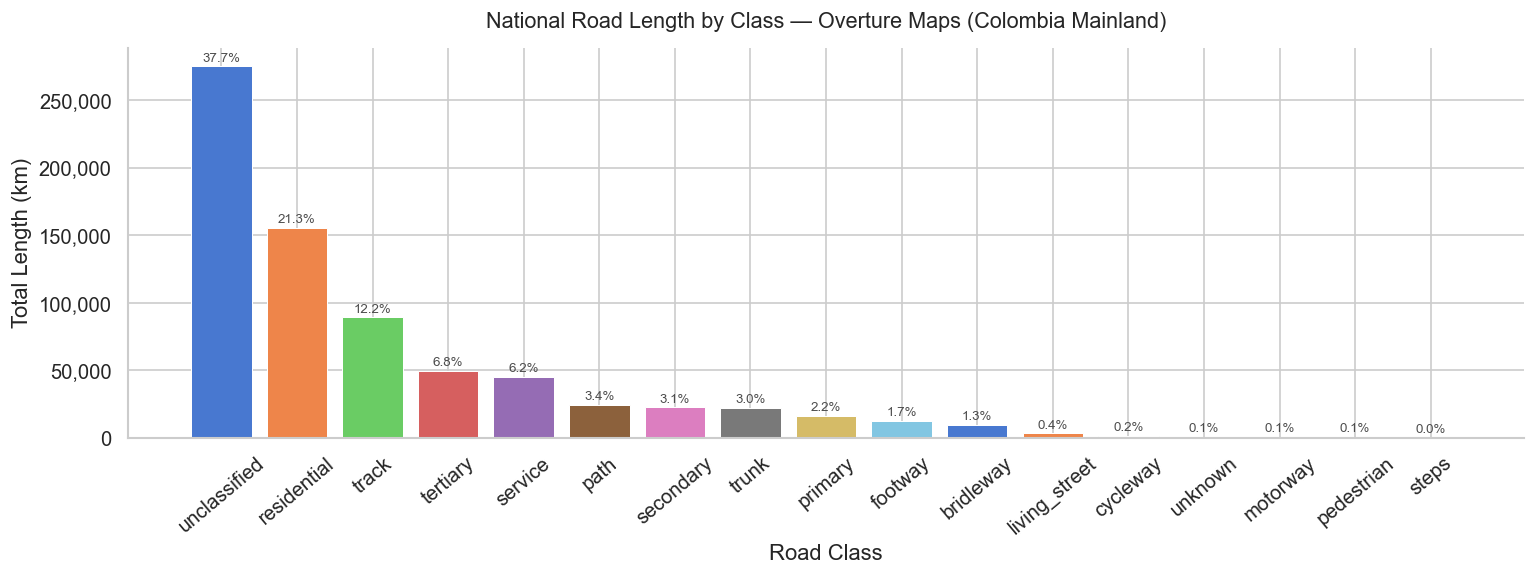

In [2]:
audit_sorted = audit.sort_values("total_length_km", ascending=False).reset_index(
    drop=True
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    audit_sorted["class"],
    audit_sorted["total_length_km"],
    color=sns.color_palette("muted", len(audit_sorted)),
    edgecolor="white",
    linewidth=0.6,
)

# Annotate pct share on top of each bar
for bar, pct in zip(bars, audit_sorted["pct_share"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="0.3",
    )

ax.set_title(
    "National Road Length by Class — Overture Maps (Colombia Mainland)",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Road Class")
ax.set_ylabel("Total Length (km)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=40)
sns.despine()
plt.tight_layout()
plt.show()

## 2. Clipped roads by class — bar chart

Road length (km) within the 698 selected municipalities (clipped geometry), aggregated by road class.


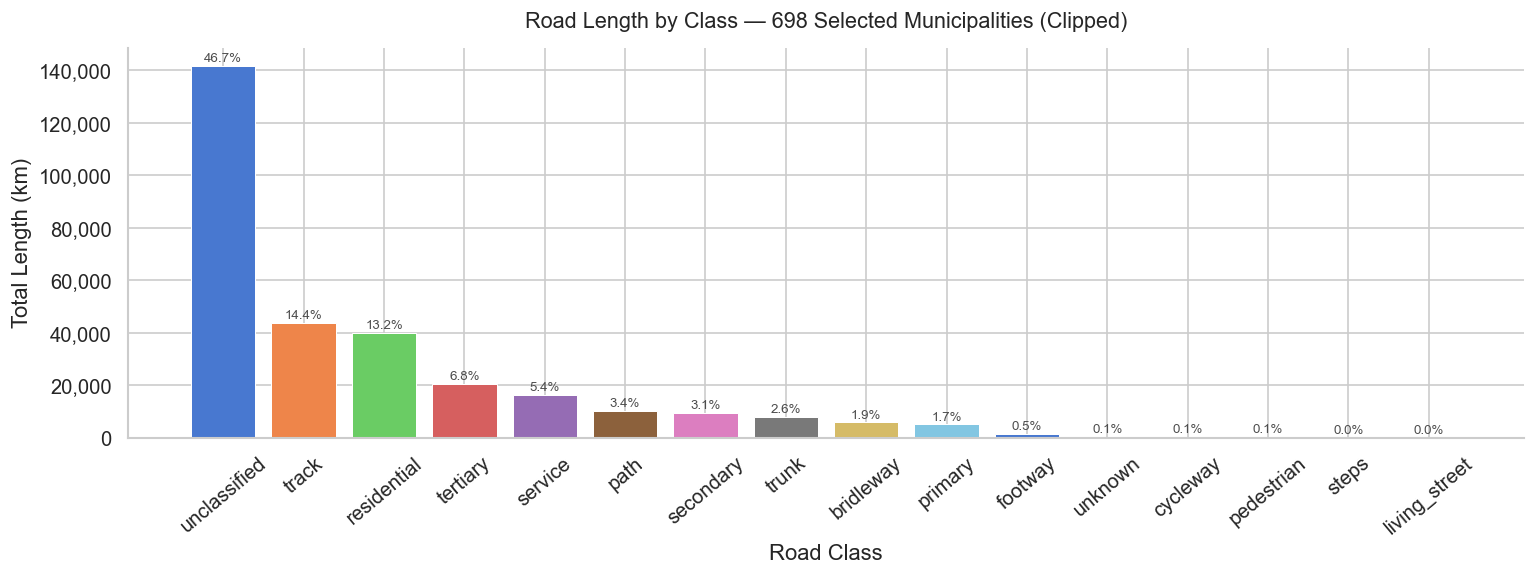

In [3]:
clipped_by_class = (
    roads.groupby("class", dropna=False)["total_length_m"]
    .sum()
    .reset_index()
    .rename(columns={"total_length_m": "total_length_km"})
)
clipped_by_class["total_length_km"] = clipped_by_class["total_length_km"] / 1000
clipped_by_class = clipped_by_class.sort_values(
    "total_length_km", ascending=False
).reset_index(drop=True)

total_clipped = clipped_by_class["total_length_km"].sum()
clipped_by_class["pct_share"] = (
    clipped_by_class["total_length_km"] / total_clipped * 100
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    clipped_by_class["class"],
    clipped_by_class["total_length_km"],
    color=sns.color_palette("muted", len(clipped_by_class)),
    edgecolor="white",
    linewidth=0.6,
)

for bar, pct in zip(bars, clipped_by_class["pct_share"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="0.3",
    )

ax.set_title(
    "Road Length by Class — 698 Selected Municipalities (Clipped)", fontsize=13, pad=12
)
ax.set_xlabel("Road Class")
ax.set_ylabel("Total Length (km)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=40)
sns.despine()
plt.tight_layout()
plt.show()

## 2.2 Scatter — national vs. clipped length by road class

Each point is one road class. X = national audit length, Y = clipped (selected municipalities) length.
Points above the diagonal would indicate more road in the municipalities than nationally — useful sanity check.


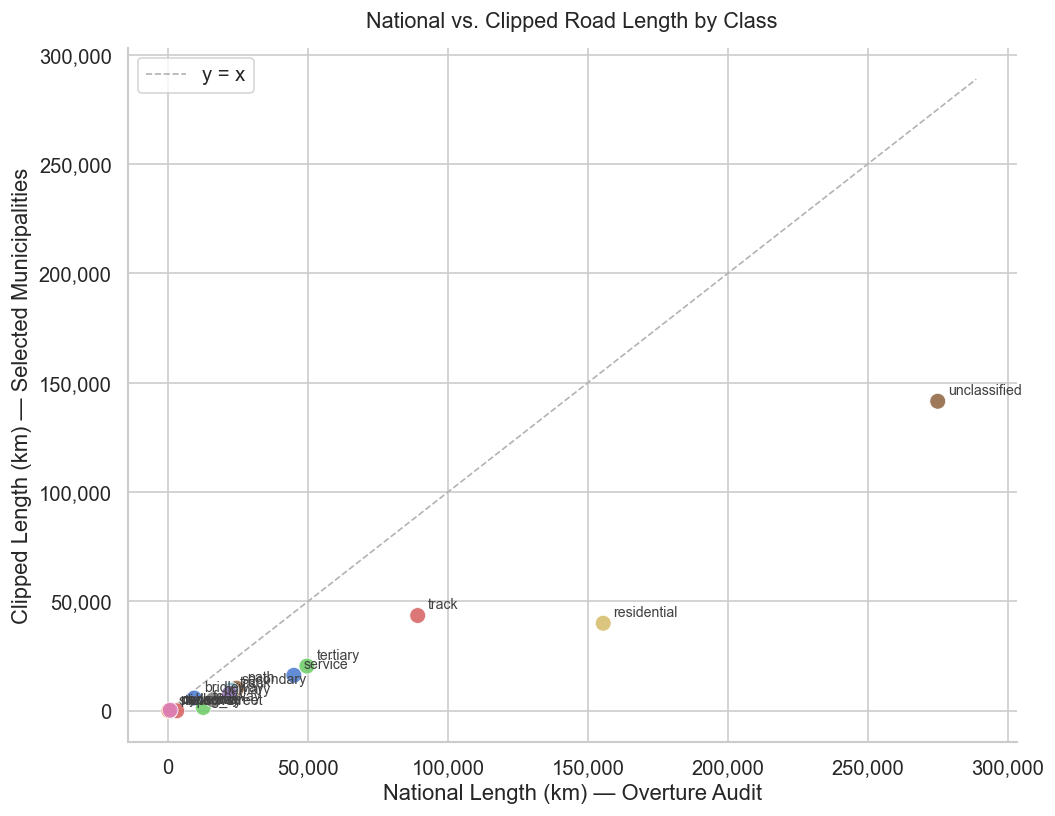

In [4]:
scatter_df = audit[["class", "total_length_km"]].rename(
    columns={"total_length_km": "national_km"}
)
scatter_df = scatter_df.merge(
    clipped_by_class[["class", "total_length_km"]].rename(
        columns={"total_length_km": "clipped_km"}
    ),
    on="class",
    how="outer",
).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    scatter_df["national_km"],
    scatter_df["clipped_km"],
    s=90,
    alpha=0.85,
    color=sns.color_palette("muted", len(scatter_df)),
    edgecolors="white",
    linewidth=0.5,
    zorder=3,
)

# Reference line y = x
lim = max(scatter_df["national_km"].max(), scatter_df["clipped_km"].max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="0.7", linewidth=1, label="y = x")

for _, row in scatter_df.iterrows():
    ax.annotate(
        row["class"],
        (row["national_km"], row["clipped_km"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8.5,
        color="0.25",
    )

ax.set_xlabel("National Length (km) — Overture Audit")
ax.set_ylabel("Clipped Length (km) — Selected Municipalities")
ax.set_title("National vs. Clipped Road Length by Class", fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 3. Zone-type share by road class — stacked 100% bar chart

For each road class, what percentage of road length falls in cabecera, centro_poblado, and rural zones?
Classes sorted by rural share (descending).


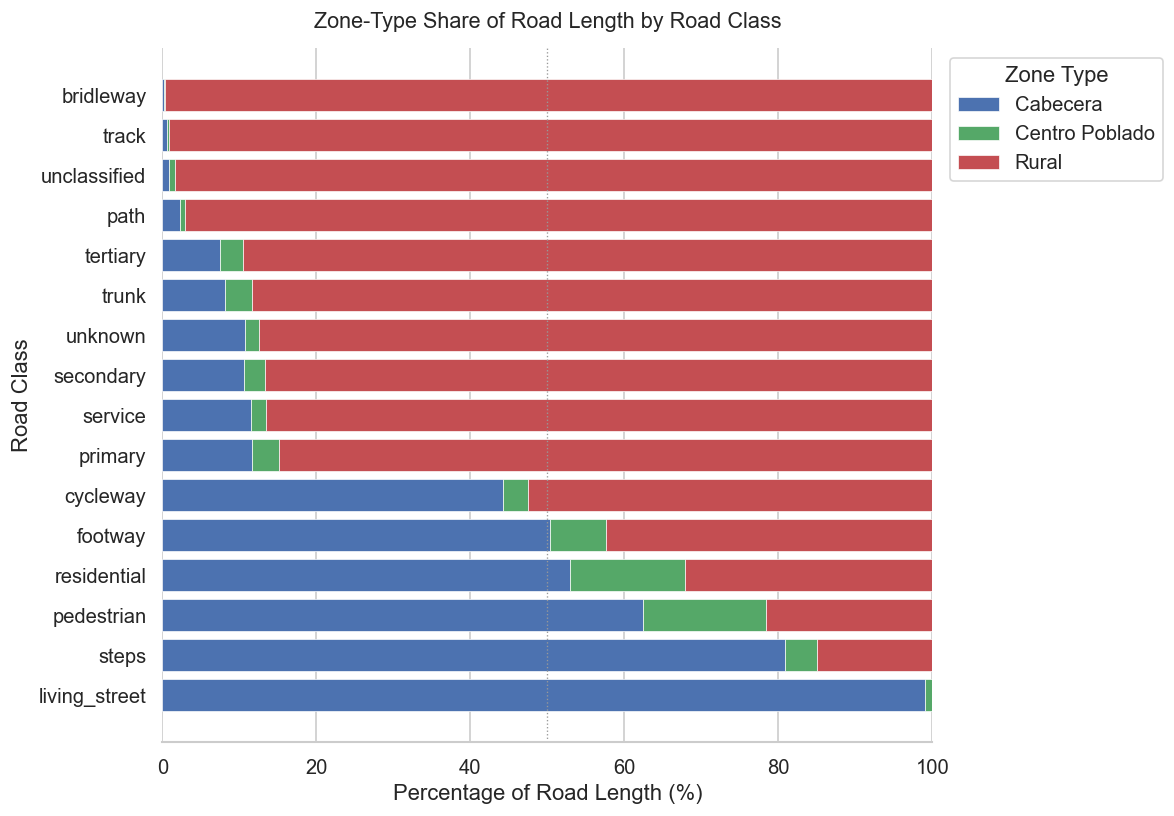

In [5]:
ZONE_COLORS = {
    "cabecera": "#4C72B0",
    "centro_poblado": "#55A868",
    "rural": "#C44E52",
}

zone_agg = (
    roads.groupby(["class", "zone_type"], dropna=False)["total_length_m"]
    .sum()
    .reset_index()
)

zone_pivot = zone_agg.pivot_table(
    index="class",
    columns="zone_type",
    values="total_length_m",
    aggfunc="sum",
    fill_value=0,
)

# Keep only recognised zone types (drop NaN columns if any)
zone_cols = [
    c for c in ["cabecera", "centro_poblado", "rural"] if c in zone_pivot.columns
]
zone_pivot = zone_pivot[zone_cols]
zone_pct = zone_pivot.div(zone_pivot.sum(axis=1), axis=0) * 100

# Sort by rural share
if "rural" in zone_pct.columns:
    zone_pct = zone_pct.sort_values(
        "rural", ascending=True
    )  # ascending so largest rural is at top in barh

fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(zone_pct))
for col in zone_cols:
    ax.barh(
        zone_pct.index,
        zone_pct[col],
        left=left,
        color=ZONE_COLORS.get(col, "#888"),
        label=col.replace("_", " ").title(),
        edgecolor="white",
        linewidth=0.4,
    )
    left += zone_pct[col].values

ax.set_xlabel("Percentage of Road Length (%)")
ax.set_ylabel("Road Class")
ax.set_title("Zone-Type Share of Road Length by Road Class", fontsize=13, pad=12)
ax.set_xlim(0, 100)
ax.axvline(50, color="0.6", linewidth=0.8, linestyle=":")
ax.legend(title="Zone Type", bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

## 4. Per-municipio road class mix

### 4a. Static — top 5 and bottom 5 municipalities by total road length


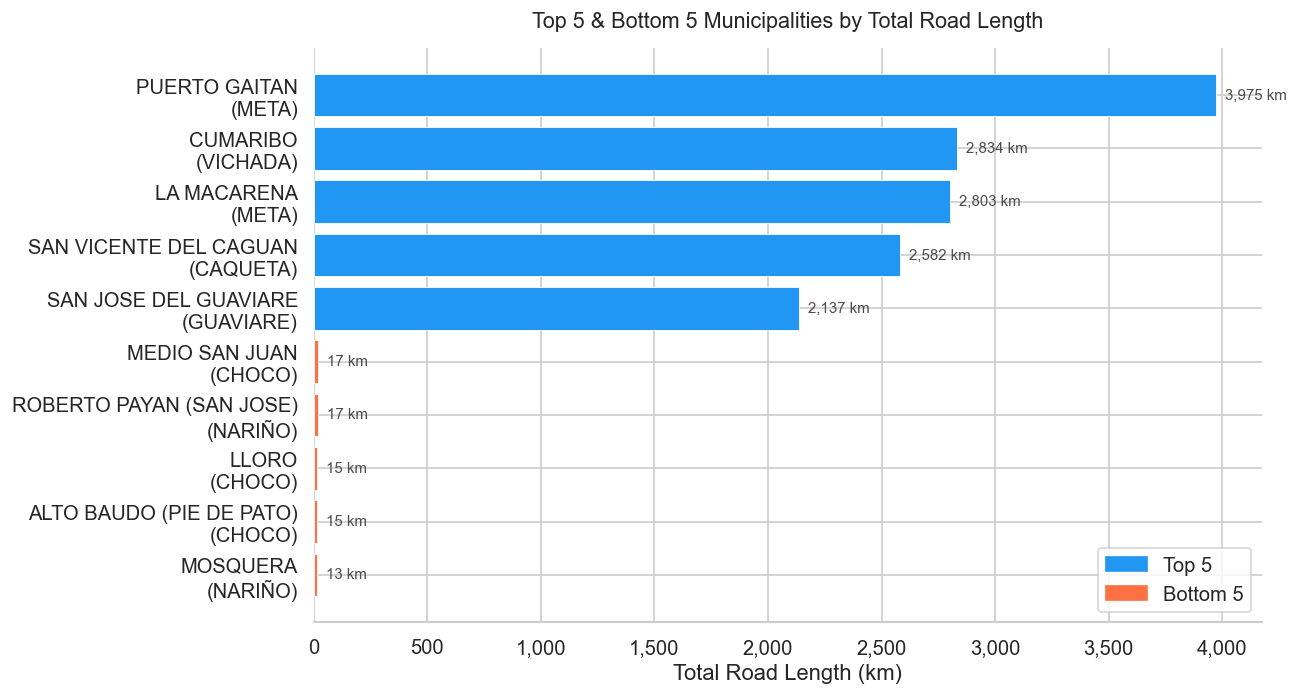

In [6]:
mpio_total = (
    roads.groupby(["mpio_id", "municipio", "departamento"])["total_length_m"]
    .sum()
    .reset_index()
)
mpio_total["total_length_km"] = mpio_total["total_length_m"] / 1000
mpio_total = mpio_total.sort_values("total_length_km", ascending=False).reset_index(
    drop=True
)

top5 = mpio_total.head(5).copy()
bot5 = mpio_total.tail(5).copy()

top5["group"] = "Top 5"
bot5["group"] = "Bottom 5"
combined = pd.concat([top5, bot5], ignore_index=True)
combined["label"] = combined["municipio"] + "\n(" + combined["departamento"] + ")"
combined = combined.sort_values(
    "total_length_km", ascending=True
)  # ascending for barh readability

colors = ["#2196F3" if g == "Top 5" else "#FF7043" for g in combined["group"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    combined["label"],
    combined["total_length_km"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)

# Value labels
for _, row in combined.iterrows():
    ax.text(
        row["total_length_km"] + combined["total_length_km"].max() * 0.01,
        row["label"],
        f"{row['total_length_km']:,.0f} km",
        va="center",
        fontsize=9,
        color="0.3",
    )

# Legend patches
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color="#2196F3", label="Top 5"),
    mpatches.Patch(color="#FF7043", label="Bottom 5"),
]
ax.legend(handles=legend_handles, loc="lower right")

ax.set_xlabel("Total Road Length (km)")
ax.set_title(
    "Top 5 & Bottom 5 Municipalities by Total Road Length", fontsize=13, pad=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine(left=True)
plt.tight_layout()
plt.show()

### 4b. Interactive — road class mix per municipio, filtered by departamento

Select a departamento from the dropdown. The chart shows each municipality as a row, with stacked bars representing the percentage of road length per road class.


In [7]:
# Pre-compute per-municipio class percentages for all departamentos
mpio_class_agg = (
    roads.groupby(["departamento", "municipio", "class"], dropna=False)[
        "total_length_m"
    ]
    .sum()
    .reset_index()
)

CLASS_PALETTE = sns.color_palette("tab20", n_colors=roads["class"].nunique())
CLASS_COLORS = dict(zip(sorted(roads["class"].dropna().unique()), CLASS_PALETTE))


def plot_departamento(departamento):
    subset = mpio_class_agg[mpio_class_agg["departamento"] == departamento]
    pivot = subset.pivot_table(
        index="municipio",
        columns="class",
        values="total_length_m",
        aggfunc="sum",
        fill_value=0,
    )
    # Percentage within each municipio
    pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    # Sort municipios by total road length (descending)
    pct = pct.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    n_mpio = len(pct)
    fig, ax = plt.subplots(figsize=(13, max(5, n_mpio * 0.42)))

    left = np.zeros(n_mpio)
    for cls in pct.columns:
        ax.barh(
            pct.index,
            pct[cls],
            left=left,
            color=CLASS_COLORS.get(cls, "#aaa"),
            label=cls,
            edgecolor="white",
            linewidth=0.3,
        )
        left += pct[cls].values

    ax.set_xlim(0, 100)
    ax.set_xlabel("% of Total Road Length")
    ax.set_ylabel("Municipio (sorted by total road length)")
    ax.set_title(f"Road Class Mix per Municipio — {departamento}", fontsize=13, pad=12)
    ax.axvline(50, color="0.6", linewidth=0.7, linestyle=":")
    ax.legend(
        title="Road Class",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
    )
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()


deptos = sorted(roads["departamento"].dropna().unique())
dropdown = widgets.Dropdown(
    options=deptos,
    value=deptos[0],
    description="Departamento:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)
out = widgets.Output()


def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        out.clear_output(wait=True)
        with out:
            plot_departamento(change["new"])


dropdown.observe(on_change)

with out:
    plot_departamento(deptos[0])

display(dropdown, out)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('AMAZONAS', 'ANTIOQUIA', 'ARAUCA'…

Output()

## 5. Road density by zone type

Total road length (km) divided by zone area (km²), giving km of road per km².
Computed per municipality per zone type, then shown as distributions across all 698 municipalities.

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_80368/3801225969.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


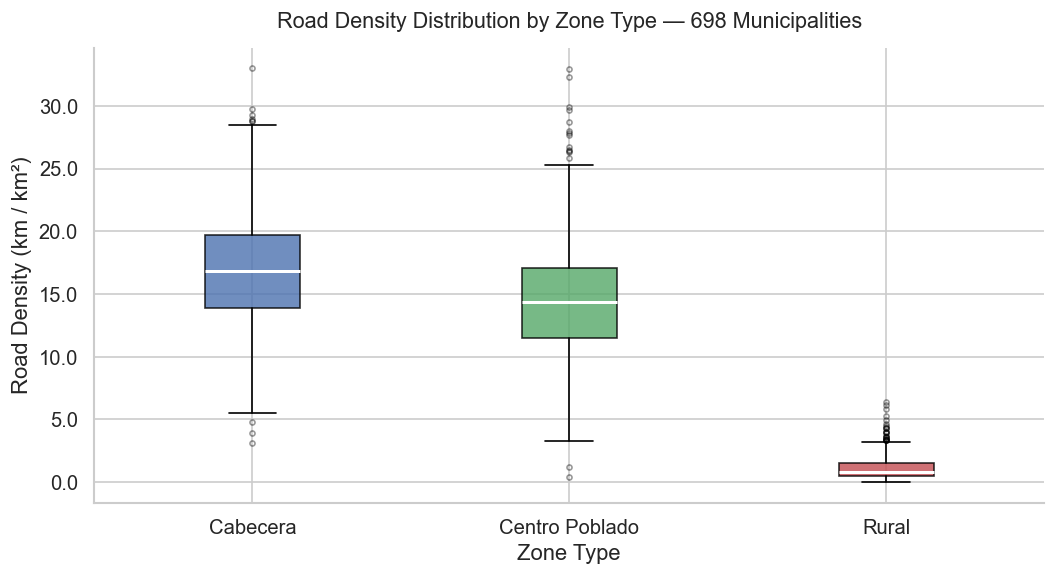


Median road density (km per km²) by zone type:
                count   mean   std   min    25%    50%    75%    max
zone_type                                                           
cabecera        698.0  16.77  4.46  3.07  13.84  16.84  19.71  33.00
centro_poblado  634.0  14.61  4.62  0.36  11.47  14.35  17.10  32.92
rural           698.0   1.12  0.96  0.00   0.44   0.81   1.54   6.34


In [8]:
ZONE_COLORS = {
    "cabecera": "#4C72B0",
    "centro_poblado": "#55A868",
    "rural": "#C44E52",
}

# Total road length per municipality × zone (all classes combined)
roads_by_zone = (
    roads.groupby(["mpio_id", "municipio", "departamento", "zone_type"])[
        "total_length_m"
    ]
    .sum()
    .reset_index()
)
roads_by_zone["total_length_km"] = roads_by_zone["total_length_m"] / 1000

# Join with zone areas
density = roads_by_zone.merge(
    areas[["mpio_id", "zone_type", "area_km2"]],
    on=["mpio_id", "zone_type"],
    how="inner",
)
density["density_km_per_km2"] = density["total_length_km"] / density["area_km2"]

# --- Box plot: density distribution by zone type ---
zone_order = ["cabecera", "centro_poblado", "rural"]
present_zones = [z for z in zone_order if z in density["zone_type"].unique()]

fig, ax = plt.subplots(figsize=(9, 5))
data_by_zone = [
    density.loc[density["zone_type"] == z, "density_km_per_km2"].dropna()
    for z in present_zones
]
bp = ax.boxplot(
    data_by_zone,
    labels=[z.replace("_", " ").title() for z in present_zones],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=1.8),
    flierprops=dict(marker="o", markersize=3, alpha=0.4, linestyle="none"),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)
for patch, zone in zip(bp["boxes"], present_zones):
    patch.set_facecolor(ZONE_COLORS[zone])
    patch.set_alpha(0.8)

ax.set_ylabel("Road Density (km / km²)")
ax.set_xlabel("Zone Type")
ax.set_title(
    "Road Density Distribution by Zone Type — 698 Municipalities", fontsize=13, pad=12
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.1f}"))
sns.despine()
plt.tight_layout()
plt.show()

# Summary table
print("\nMedian road density (km per km²) by zone type:")
print(
    density.groupby("zone_type")["density_km_per_km2"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(2)
    .to_string()
)